**Step 1: Import Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Load Dataset**

In [13]:
df = pd.read_csv("/content/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [15]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [16]:
df.dropna(inplace=True)

**Step 3: Data Understanding**

In [18]:
df.info()
df.describe()

# Check fraud vs normal
print(df['Class'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 23857 entries, 0 to 23856
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    23857 non-null  int64  
 1   V1      23857 non-null  float64
 2   V2      23857 non-null  float64
 3   V3      23857 non-null  float64
 4   V4      23857 non-null  float64
 5   V5      23857 non-null  float64
 6   V6      23857 non-null  float64
 7   V7      23857 non-null  float64
 8   V8      23857 non-null  float64
 9   V9      23857 non-null  float64
 10  V10     23857 non-null  float64
 11  V11     23857 non-null  float64
 12  V12     23857 non-null  float64
 13  V13     23857 non-null  float64
 14  V14     23857 non-null  float64
 15  V15     23857 non-null  float64
 16  V16     23857 non-null  float64
 17  V17     23857 non-null  float64
 18  V18     23857 non-null  float64
 19  V19     23857 non-null  float64
 20  V20     23857 non-null  float64
 21  V21     23857 non-null  float64
 22  V22

**Step 4: Data Visualization**

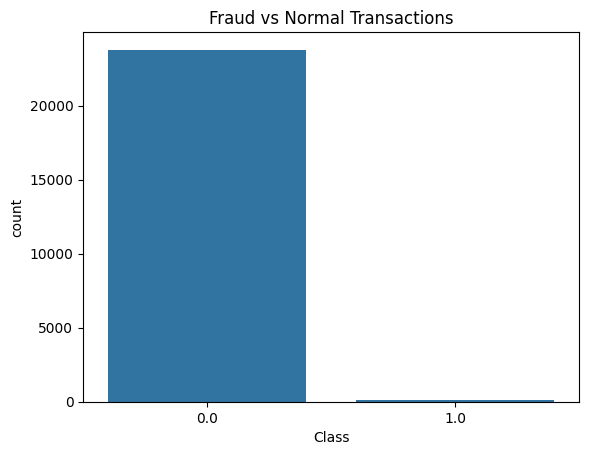

In [19]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

**Step 5: Handle Imbalanced Data**

In [20]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

normal_sample = normal.sample(n=len(fraud))

new_df = pd.concat([fraud, normal_sample], axis=0)

print(new_df['Class'].value_counts())

Class
1.0    88
0.0    88
Name: count, dtype: int64


**Step 6: Split Data**

In [26]:
X = new_df.drop(columns='Class', axis=1)
y = new_df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Step 7: Train Model**

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**Step 8: Prediction**

In [30]:
y_pred = model.predict(X_test)
y_pred

array([1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1.,
       1., 1.])

**Step 9: Evaluation**

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9722222222222222
Confusion Matrix:
 [[17  0]
 [ 1 18]]
Report:
               precision    recall  f1-score   support

         0.0       0.94      1.00      0.97        17
         1.0       1.00      0.95      0.97        19

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



**Step 10: Improve Model**

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.9722222222222222


**Step 11: Save Model**

In [33]:
import pickle

pickle.dump(model, open("fraud_model.pkl", "wb"))